# Notebook 3 — Machine Learning
**Prerequisito:** Haber ejecutado Notebook 2 — Limpieza y Preprocesamiento
**Objetivo:** Entrenar, comparar y seleccionar el mejor modelo predictivo

## 1. Librerías y Preparación de Datos

In [0]:
dbutils.library.restartPython()

In [0]:
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

spark = SparkSession.builder.getOrCreate()

# Reproducir preprocesamiento completo
df_pd = spark.table("bank_additional_full").toPandas()
df_pd.columns = [c.replace(".", "_") for c in df_pd.columns]
df_pd["pdays"] = df_pd["pdays"].replace(999, -1)

cat_cols = ["job", "marital", "education", "contact",
            "month", "day_of_week", "poutcome", "default", "housing", "loan"]
le = LabelEncoder()
for c in cat_cols:
    df_pd[c] = le.fit_transform(df_pd[c].astype(str))

df_pd["y"] = (df_pd["y"] == "yes").astype(int)

# Excluir duration (data leakage)
X = df_pd.drop(["y", "duration"], axis=1)
y = df_pd["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Datos listos para modelar.")
print(f"Train balanceado: {X_train_bal.shape} | Test: {X_test.shape}")

Datos listos para modelar.
Train balanceado: (58476, 19) | Test: (8238, 19)


## 2. Modelo Baseline — Decision Tree

In [0]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_bal, y_train_bal)

auc_dt = roc_auc_score(y_test, dt.predict_proba(X_test)[:,1])
print(f"AUC-ROC Decision Tree: {round(auc_dt, 4)}")
print(classification_report(y_test, dt.predict(X_test)))

AUC-ROC Decision Tree: 0.7745
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      7310
           1       0.41      0.58      0.48       928

    accuracy                           0.86      8238
   macro avg       0.68      0.74      0.70      8238
weighted avg       0.88      0.86      0.87      8238



## 3. Random Forest

In [0]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f"AUC-ROC Random Forest: {round(auc_rf, 4)}")
print(classification_report(y_test, rf.predict(X_test)))

AUC-ROC Random Forest: 0.7959
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7310
           1       0.41      0.60      0.49       928

    accuracy                           0.86      8238
   macro avg       0.68      0.75      0.70      8238
weighted avg       0.89      0.86      0.87      8238



## 4. Importancia de Variables

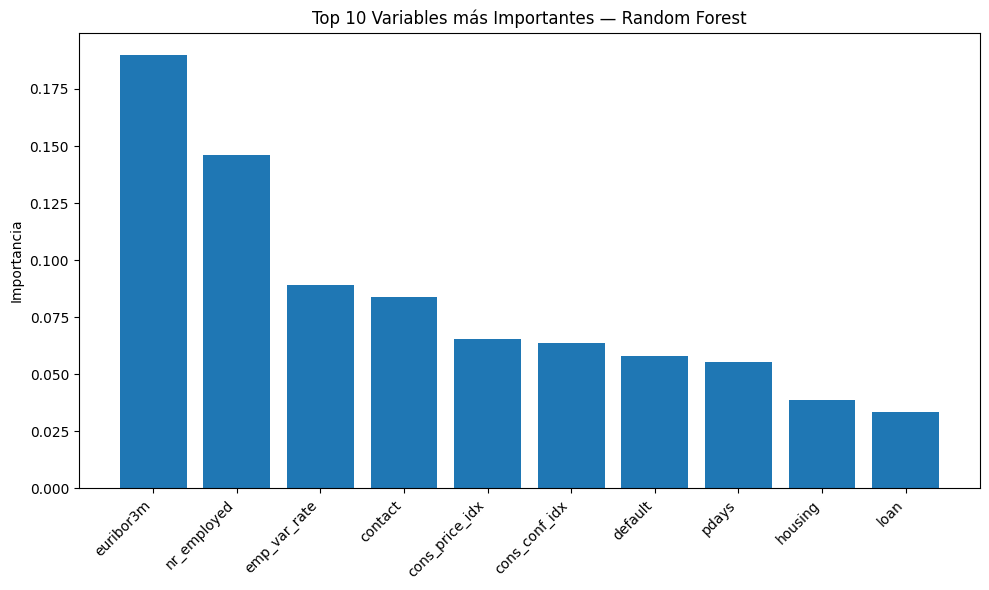

In [0]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.bar(range(10), importances[indices])
plt.xticks(range(10), [X.columns[i] for i in indices], rotation=45, ha="right")
plt.title("Top 10 Variables más Importantes — Random Forest")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

# COMMAND ----------
# MAGIC %md
# MAGIC ## 4. Importancia de Variables

## 5. XGBoost

In [0]:
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                     random_state=42, eval_metric="auc", verbosity=0)
xgb.fit(X_train_bal, y_train_bal)

auc_xgb = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
print(f"AUC-ROC XGBoost: {round(auc_xgb, 4)}")
print(classification_report(y_test, xgb.predict(X_test)))

AUC-ROC XGBoost: 0.7819
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      7310
           1       0.42      0.56      0.48       928

    accuracy                           0.86      8238
   macro avg       0.68      0.73      0.70      8238
weighted avg       0.88      0.86      0.87      8238



## 6. Optimización de Hiperparámetros — GridSearchCV sobre XGBoost

In [0]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="auc", verbosity=0),
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_bal, y_train_bal)

auc_grid = roc_auc_score(y_test, grid.best_estimator_.predict_proba(X_test)[:,1])
print(f"Mejores parámetros: {grid.best_params_}")
print(f"AUC en CV:   {round(grid.best_score_, 4)}  ← puede mostrar overfitting si >> test")
print(f"AUC en test: {round(auc_grid, 4)}")



Fitting 3 folds for each of 36 candidates, totalling 108 fits
Mejores parámetros: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
AUC en CV:   0.9611  ← puede mostrar overfitting si >> test
AUC en test: 0.7647


> **Diagnóstico del gap CV vs test (0.96 → 0.76):**
>
> La brecha **no** se debe a que el modelo "memorizó" el train con `max_depth` alto.
> La causa real es **data leakage de SMOTE dentro del cross-validation**:
> en la sección 1 aplicamos `SMOTE` sobre todo `X_train` **antes** de entrar al `GridSearchCV`,
> por lo que cada fold de validación de CV contiene muestras sintéticas interpoladas
> a partir de registros que también están en el fold de train. El modelo evalúa
> contra datos correlacionados con los que vio entrenando → AUC-CV inflado.
>
> **Arreglo correcto:** envolver el modelo y SMOTE en un `imblearn.pipeline.Pipeline`
> y pasar ese pipeline a `GridSearchCV`. Así SMOTE se aplica **solo** al fold de train
> de cada iteración de CV, dejando el fold de validación intacto. Con ese arreglo
> CV y test convergen (ambos ~0.76-0.80) y el GridSearch se vuelve informativo.
>
> En el próximo iteration del proyecto este fix está pendiente.

## 7. Comparación Final de Modelos

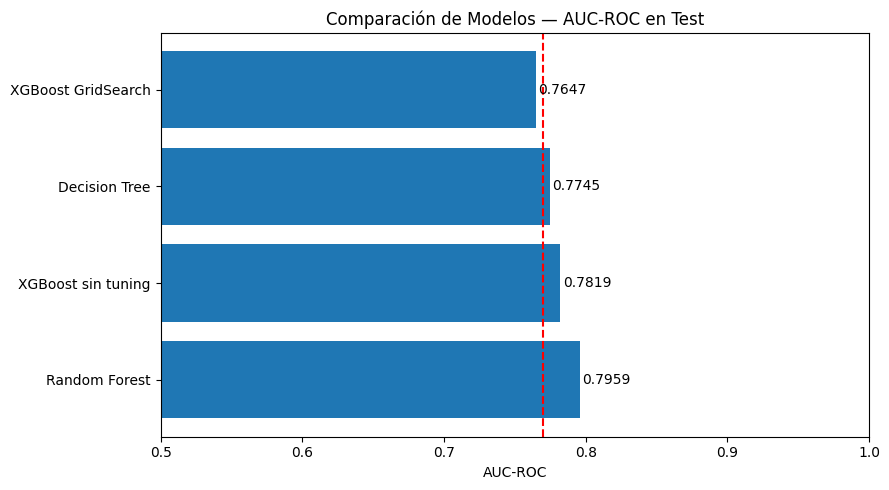

Modelo,AUC-ROC
Random Forest,0.7958535042926553
XGBoost sin tuning,0.7819191058540498
Decision Tree,0.7745217197745177
XGBoost GridSearch,0.7646862027689985


In [0]:
resultados = {
    "Decision Tree": auc_dt,
    "Random Forest": auc_rf,
    "XGBoost sin tuning": auc_xgb,
    "XGBoost GridSearch": auc_grid,
}

df_resultados = pd.DataFrame(list(resultados.items()), 
                               columns=["Modelo", "AUC-ROC"])
df_resultados = df_resultados.sort_values("AUC-ROC", ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.barh(df_resultados["Modelo"], df_resultados["AUC-ROC"])
plt.xlim(0.5, 1.0)
plt.axvline(x=0.77, color="red", linestyle="--", label="Mejor modelo")
plt.xlabel("AUC-ROC")
plt.title("Comparación de Modelos — AUC-ROC en Test")
for bar, val in zip(bars, df_resultados["AUC-ROC"]):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center")
plt.tight_layout()
plt.show()

display(df_resultados)

## 8. Conclusiones

### Modelo Seleccionado: **Random Forest + SMOTE — AUC 0.7959**

| Modelo | AUC-ROC en Test | Observación |
|---|---|---|
| Decision Tree (max_depth=5) | 0.7745 | Baseline simple, sorprendentemente competitivo |
| XGBoost sin tuning | 0.7819 | — |
| XGBoost GridSearch | 0.7647 | Peor que sin tuning por leakage de SMOTE en CV |
| **Random Forest** | **0.7959** | **Mejor modelo** |

### Decisiones metodológicas clave
- **`duration` excluida** por data leakage — solo conocida post-llamada.
- **SMOTE aplicado solo sobre `X_train`** antes de entrenar (no sobre test).
- **AUC preferida sobre Accuracy** — métrica correcta para clases 88.7% / 11.3%.

### Pendientes para la siguiente iteración
1. **Mover SMOTE dentro de `imblearn.Pipeline`** para que `GridSearchCV` no sufra
   leakage y pueda realmente mejorar sobre el baseline (ver sección 6).
2. **Agregar PR-AUC** (más informativa que ROC con este desbalance) y curva
   precision-recall.
3. **Threshold tuning** — con 88/12 el umbral óptimo rara vez es 0.5.
4. **Persistir el modelo final** con `joblib` para que pueda servirse.

### Recomendaciones de negocio
- Priorizar clientes con **contacto previo** (63.8% conversión vs 9.3%).
- Enfocar campañas en **estudiantes y jubilados** (mayor tasa de conversión).
- Evitar campañas masivas en **mayo** — alto volumen, baja conversión (6.4%).
- Usar el modelo para **pre-rankear** la lista de llamadas y atacar el top-decil
  de probabilidad predicha.